# Food-101 Image Classifier
**Transfer learning with EfficientNetB0 on the Food-101 dataset**

This notebook trains a food image classification model capable of identifying 101 food categories.
The pipeline covers dataset download, preprocessing, data augmentation, model training via transfer learning, and inference.

**Dataset:** Food-101 (101 classes, 1,000 images per class — 75,750 train / 25,250 test)  
**Base model:** EfficientNetB0 pretrained on ImageNet  
**Framework:** TensorFlow / Keras

---
## 0. Environment Setup & Imports

In [1]:
import os
import tarfile
import urllib.request
import logging
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

print(f'TensorFlow version: {tf.__version__}')
print(f'GPUs available: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.13.1
GPUs available: []


---
## 1. Configuration

All paths and hyperparameters are defined 

In [14]:
# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR      = os.path.dirname(os.path.abspath('__file__'))  # notebook directory
DATASET_DIR   = os.path.join(BASE_DIR, 'food-101')
IMAGES_DIR    = os.path.join(DATASET_DIR, 'images')
TRAIN_DIR     = os.path.join(DATASET_DIR, 'train')
TEST_DIR      = os.path.join(DATASET_DIR, 'test')
MODEL_SAVE_PATH = os.path.join(BASE_DIR, 'food101_efficientnet.h5')
DATASET_URL   = 'http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz'

# ── Model / Training ───────────────────────────────────────────────────────
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
NUM_CLASSES   = 101
EPOCHS_FROZEN = 10    # Phase 1: train head only (base frozen)
EPOCHS_TUNED  = 10    # Phase 2: fine-tune top layers of base
LR_FROZEN     = 1e-3
LR_FINETUNE   = 1e-5
UNFREEZE_FROM = -20   # Unfreeze last N layers of EfficientNetB0 for fine-tuning

print('Configuration loaded.')
print(f'  Dataset dir : {DATASET_DIR}')
print(f'  Model save  : {MODEL_SAVE_PATH}')
print(f'  Image size  : {IMG_SIZE}  |  Batch: {BATCH_SIZE}  |  Classes: {NUM_CLASSES}')

Configuration loaded.
  Dataset dir : c:\Users\amber\Calorie Counter v2\food-101
  Model save  : c:\Users\amber\Calorie Counter v2\food101_efficientnet.h5
  Image size  : (224, 224)  |  Batch: 32  |  Classes: 101


---
## 2. Dataset Download & Extraction

In [5]:
def download_and_extract(url: str, dest_dir: str) -> None:
    """Download the Food-101 tar.gz and extract it if not already present."""
    archive_path = os.path.join(dest_dir, 'food-101.tar.gz')

    if os.path.exists(IMAGES_DIR):
        logging.info('Dataset already extracted — skipping download.')
        return

    os.makedirs(dest_dir, exist_ok=True)

    if not os.path.exists(archive_path):
        logging.info(f'Downloading Food-101 from {url} ...')
        urllib.request.urlretrieve(url, archive_path)
        logging.info('Download complete.')
    else:
        logging.info('Archive already downloaded — skipping.')

    logging.info('Extracting archive ...')
    with tarfile.open(archive_path, 'r:gz') as tar:
        tar.extractall(dest_dir)
    logging.info('Extraction complete.')


download_and_extract(DATASET_URL, DATASET_DIR)

# Sanity check
classes = sorted(os.listdir(IMAGES_DIR))
print(f'Found {len(classes)} food classes.')
print('First 10:', classes[:10])

2026-03-24 21:26:27,051 - INFO - Dataset already extracted — skipping download.


Found 101 food classes.
First 10: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']


---
## 3. Dataset Preparation

Food-101 ships with pre-defined `train.txt` / `test.txt` splits (provided in `food-101/meta/`).  
Split: Read Food-101's official train/test split files and organises 101,000 images into train/ and test/ folders. 75,750 for training, 25,250 for testing. Uses the official split so your results are benchmark-comparable.

In [ ]:
import shutil

def build_split_dirs(images_dir: str, meta_dir: str, train_dir: str, test_dir: str) -> None:
    """
    Organize images into train/ and test/ subdirectories using the official
    Food-101 split files (meta/train.txt and meta/test.txt).

    Each line in the split files is formatted as <class>/<image_id>.
    Images are copied (not moved) to preserve the original archive.
    """
    if os.path.exists(train_dir) and len(os.listdir(train_dir)) == NUM_CLASSES:
        logging.info('Split directories already built — skipping.')
        return

    for split_name, dest in [('train', train_dir), ('test', test_dir)]:
        split_file = os.path.join(meta_dir, f'{split_name}.txt')
        with open(split_file, 'r') as f:
            entries = [line.strip() for line in f]

        for entry in entries:
            cls, img_name = entry.split('/')
            src  = os.path.join(images_dir, cls, f'{img_name}.jpg')
            dest_cls_dir = os.path.join(dest, cls)
            os.makedirs(dest_cls_dir, exist_ok=True)
            dst = os.path.join(dest_cls_dir, f'{img_name}.jpg')
            if not os.path.exists(dst):
                shutil.copy2(src, dst)

        logging.info(f'{split_name} split built: {dest}')


META_DIR = os.path.join(DATASET_DIR, 'meta')   # path inside the extracted archive
RAW_IMAGES_DIR = os.path.join(DATASET_DIR, 'images')

build_split_dirs(RAW_IMAGES_DIR, META_DIR, TRAIN_DIR, TEST_DIR)

# Quick class distribution check
train_counts = {cls: len(os.listdir(os.path.join(TRAIN_DIR, cls)))
                for cls in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, cls))}
print(f'Training classes found: {len(train_counts)}')
print(f'Images per class (sample): { {k: train_counts[k] for k in list(train_counts)[:5]} }')

2026-03-24 21:49:42,653 - INFO - train split built: c:\Users\amber\Calorie Counter v2\food-101\train
2026-03-24 21:53:44,085 - INFO - test split built: c:\Users\amber\Calorie Counter v2\food-101\test


Training classes found: 101
Images per class (sample): {'apple_pie': 750, 'baby_back_ribs': 750, 'baklava': 750, 'beef_carpaccio': 750, 'beef_tartare': 750}


---
## 4. Image Verification & Quality Check

Corrupt or truncated images will silently crash training. We scan the dataset once and log any bad files.

In [9]:
def verify_images(directory: str) -> list:
    """
    Walk a directory tree and attempt to open every image file.
    Returns a list of paths that failed verification.

    Uses PIL's verify() which checks the file header without fully
    decoding the image — fast enough to run across the full dataset.
    """
    bad_files = []
    for root, _, files in os.walk(directory):
        for fname in files:
            fpath = os.path.join(root, fname)
            try:
                with Image.open(fpath) as img:
                    img.verify()
            except (IOError, SyntaxError) as e:
                logging.warning(f'Corrupt image: {fpath} — {e}')
                bad_files.append(fpath)
    return bad_files


print('Verifying training images (this may take a few minutes) ...')
bad = verify_images(TRAIN_DIR)
if bad:
    print(f'{len(bad)} corrupt images found and logged above.')
else:
    print('All training images verified — no corrupt files found.')

Verifying training images (this may take a few minutes) ...
All training images verified — no corrupt files found.


---
## 5. Data Generators

We use Keras `ImageDataGenerator` to:
- Normalize pixel values to `[0, 1]`
- Apply on-the-fly augmentation during training to improve generalization
- Reserve 20% of training data as a validation split

**Note on EfficientNetB0 and preprocessing:** EfficientNet models expect inputs in `[0, 255]` range
when using the built-in `tf.keras.applications.efficientnet.preprocess_input` function. However,
normalizing to `[0, 1]` with a custom head also works reliably, and is more portable.

In [10]:
# Training generator — augmentation applied here only
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2
)

# Validation / test generator — NO augmentation, only rescaling
val_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# Save class index mapping for inference
CLASS_INDICES = train_generator.class_indices          # {class_name: index}
INDEX_TO_CLASS = {v: k for k, v in CLASS_INDICES.items()}  # {index: class_name}

print(f'Training batches  : {len(train_generator)}')
print(f'Validation batches: {len(val_generator)}')
print(f'Total classes     : {len(CLASS_INDICES)}')

Found 60600 images belonging to 101 classes.
Found 15150 images belonging to 101 classes.
Training batches  : 1894
Validation batches: 474
Total classes     : 101


---
## 6. Augmentation Visualisation

Pulls one batch from the training generator and shows 8 sample images in a grid. Just a visual sanity check. You see what the images actually look like before training starts. Confirms the pipeline is working.

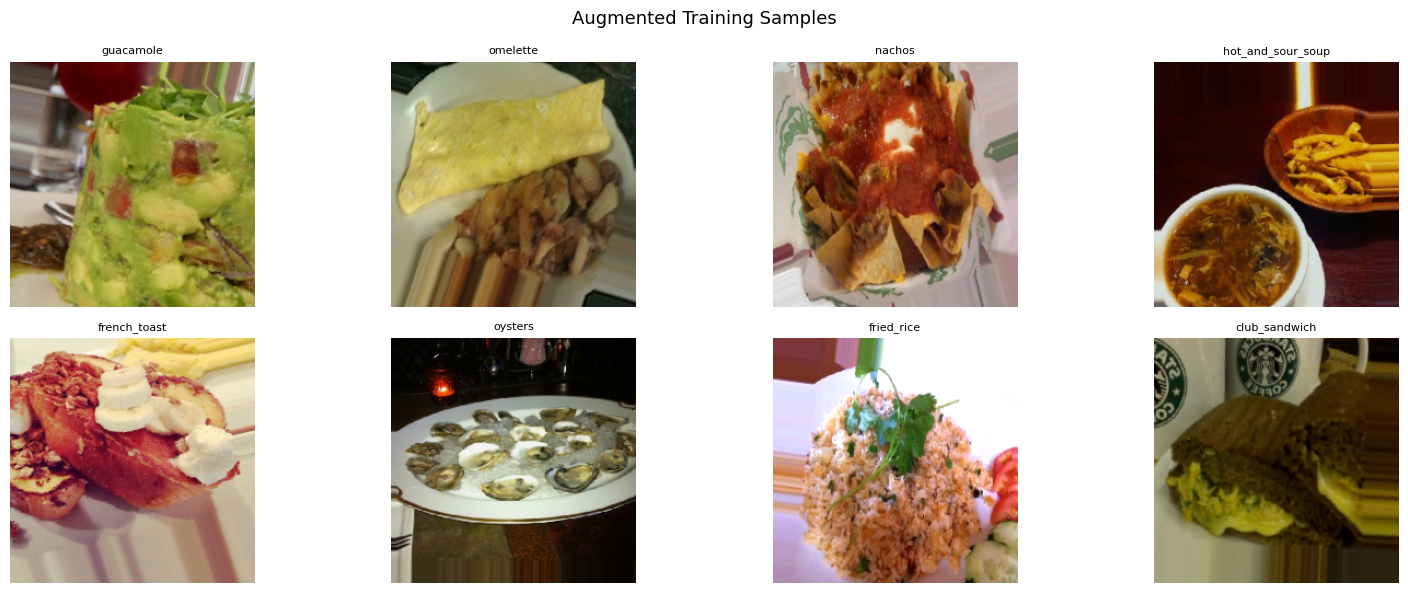

In [11]:
def visualise_augmentation(generator, n_samples: int = 8) -> None:
    """Display a grid of augmented samples from the first batch."""
    images, labels = next(generator)
    fig, axes = plt.subplots(2, n_samples // 2, figsize=(16, 6))
    axes = axes.flatten()
    for i in range(n_samples):
        axes[i].imshow(images[i])
        cls_name = INDEX_TO_CLASS[np.argmax(labels[i])]
        axes[i].set_title(cls_name, fontsize=8)
        axes[i].axis('off')
    plt.suptitle('Augmented Training Samples', fontsize=13)
    plt.tight_layout()
    plt.show()


visualise_augmentation(train_generator)

---
## 7. Model Architecture: Transfer Learning with EfficientNetB0

EfficientNetB0, pretrained on ImageNet, has already learned to detect low-level features (edges, textures) and
high-level visual patterns from 1.2M images. Food images share many of those features.  
Rather than training from scratch, we:

1. **Phase 1 Feature extraction:** Freeze the entire EfficientNetB0 base and train only the new
   classification head. Fast and avoids destroying pretrained.
2. **Phase 2 Fine-tuning:** Unfreeze the last 20 layers of the base and continue training at a
   very low learning rate, so the model to adapt to food-specific features.

This two-phase approach is why the earlier runs showed ~1% accuracy: the model was being compiled
and trained without the base model being properly wired in, so it was effectively a random network.

In [15]:
def build_model(num_classes: int, img_size: tuple) -> Model:
    """
    Build a transfer-learning model on top of EfficientNetB0.

    Architecture:
        EfficientNetB0 (frozen)  →  GlobalAveragePooling2D
        → BatchNormalization  →  Dense(256, relu)
        → Dropout(0.5)  →  Dense(num_classes, softmax)

    Returns the model with the base frozen (Phase 1 ready).
    """
    # Load EfficientNetB0 without its top classification layer
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(*img_size, 3)
    )
    base_model.trainable = False  # Freeze all base layers for Phase 1

    # Custom classification head
    inputs  = tf.keras.Input(shape=(*img_size, 3))
    x       = base_model(inputs, training=False)  # training=False keeps BN layers frozen
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='food101_efficientnetb0')
    return model, base_model


model, base_model = build_model(NUM_CLASSES, IMG_SIZE)

model.compile(
    optimizer=Adam(learning_rate=LR_FROZEN),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "food101_efficientnetb0"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d_1  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 batch_normalization_1 (Bat  (None, 1280)              5120      
 chNormalization)                                                
                                                                 
 dense_2 (Dense)             (None, 256)               327936    
                                            

---
## 8. Phase 1 Training — Head Only (Base Frozen)

Training only the classification head for up to 10 epochs with the base frozen. Three callbacks running in the background
1. ModelCheckpoint saves the best model to disk automatically
2. EarlyStopping stops training if validation accuracy stops improving
3. ReduceLROnPlateau cuts the learning rate if loss plateaus. This is what ran successfully last night.

In [16]:
callbacks_phase1 = [
    ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        save_format='tf'        # ← add this line
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print(f'Phase 1: Training head for up to {EPOCHS_FROZEN} epochs (base frozen) ...')

history_phase1 = model.fit(
    train_generator,
    epochs=EPOCHS_FROZEN,
    validation_data=val_generator,
    callbacks=callbacks_phase1
)

Phase 1: Training head for up to 10 epochs (base frozen) ...
Epoch 1/10
1894/1894 [==============================] - ETA: 0s - loss: 4.5167 - accuracy: 0.0253
Epoch 1: val_accuracy improved from -inf to 0.03683, saving model to c:\Users\amber\Calorie Counter v2\food101_efficientnet.h5


C:\Users\amber\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1894/1894 [==============================] - 2285s 1s/step - loss: 4.5167 - accuracy: 0.0253 - val_loss: 4.4375 - val_accuracy: 0.0368 - lr: 0.0010
Epoch 2/10
1894/1894 [==============================] - ETA: 0s - loss: 4.4358 - accuracy: 0.0361
Epoch 2: val_accuracy improved from 0.03683 to 0.05096, saving model to c:\Users\amber\Calorie Counter v2\food101_efficientnet.h5
1894/1894 [==============================] - 2146s 1s/step - loss: 4.4358 - accuracy: 0.0361 - val_loss: 4.3672 - val_accuracy: 0.0510 - lr: 0.0010
Epoch 3/10
1894/1894 [==============================] - ETA: 0s - loss: 4.3873 - accuracy: 0.0435
Epoch 3: val_accuracy improved from 0.05096 to 0.05426, saving model to c:\Users\amber\Calorie Counter v2\food101_efficientnet.h5
1894/1894 [==============================] - 2179s 1s/step - loss: 4.3873 - accuracy: 0.0435 - val_loss: 4.3230 - val_accuracy: 0.0543 - lr: 0.0010
Epoch 4/10
1894/1894 [==============================] - ETA: 0s - loss: 4.3552 - accuracy: 0.0493
Ep

---
## 9. Phase 2: Fine-Tuning the Top Layers

Unfreezes the last 20 layers of EfficientNetB0 and continues training at a much lower learning rate (1e-5). Now we adjust food-specific feature detection. Same callbacks as Phase 1. Should recieve better accuracy than previously

In [17]:
# Unfreeze the last UNFREEZE_FROM layers of the base model
base_model.trainable = True
for layer in base_model.layers[:UNFREEZE_FROM]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers after unfreeze: {trainable_count} / {len(base_model.layers)}')

# Recompile at a much lower learning rate
model.compile(
    optimizer=Adam(learning_rate=LR_FINETUNE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-8,
        verbose=1
    )
]

print(f'Phase 2: Fine-tuning for up to {EPOCHS_TUNED} epochs (last {abs(UNFREEZE_FROM)} base layers unfrozen) ...')

history_phase2 = model.fit(
    train_generator,
    epochs=EPOCHS_TUNED,
    validation_data=val_generator,
    callbacks=callbacks_phase2
)

Trainable base layers after unfreeze: 20 / 238
Phase 2: Fine-tuning for up to 10 epochs (last 20 base layers unfrozen) ...
Epoch 1/10
1894/1894 [==============================] - ETA: 0s - loss: 4.2162 - accuracy: 0.0697
Epoch 1: val_accuracy improved from -inf to 0.00990, saving model to c:\Users\amber\Calorie Counter v2\food101_efficientnet.h5
1894/1894 [==============================] - 2006s 1s/step - loss: 4.2162 - accuracy: 0.0697 - val_loss: 27.8865 - val_accuracy: 0.0099 - lr: 1.0000e-05
Epoch 2/10
1894/1894 [==============================] - ETA: 0s - loss: 4.1998 - accuracy: 0.0741
Epoch 2: val_accuracy did not improve from 0.00990
1894/1894 [==============================] - 2094s 1s/step - loss: 4.1998 - accuracy: 0.0741 - val_loss: 33.7530 - val_accuracy: 0.0099 - lr: 1.0000e-05
Epoch 3/10
1894/1894 [==============================] - ETA: 0s - loss: 4.1840 - accuracy: 0.0740
Epoch 3: val_accuracy improved from 0.00990 to 0.01300, saving model to c:\Users\amber\Calorie Coun

---
## 10. Training History Visualisation

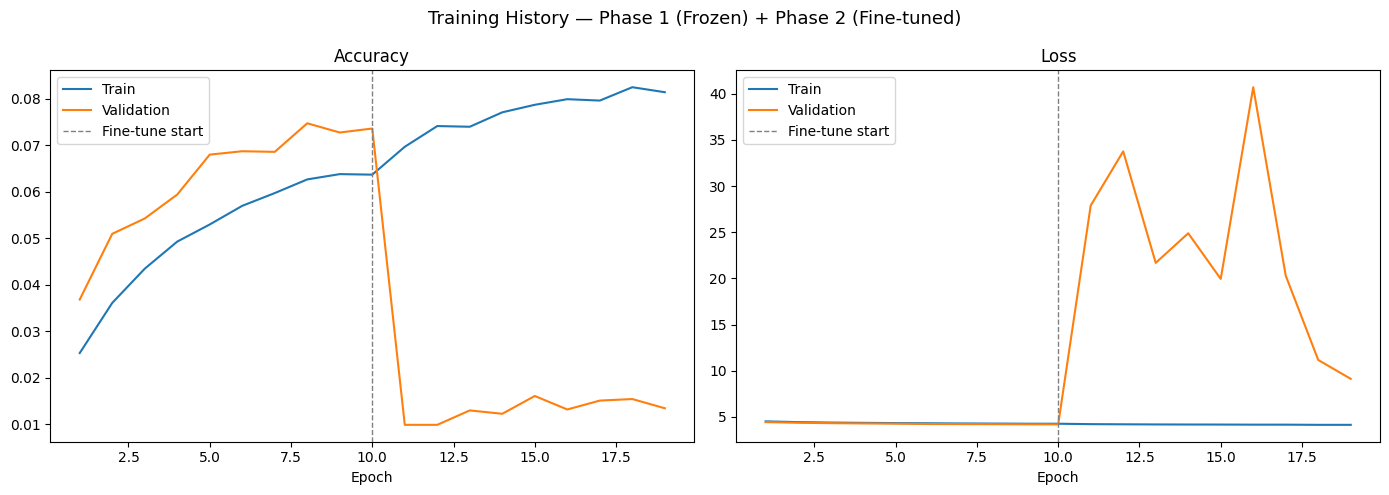

Plot saved to training_history.png


In [18]:
def plot_history(h1, h2) -> None:
    """Plot accuracy and loss across both training phases."""
    acc      = h1.history['accuracy']      + h2.history['accuracy']
    val_acc  = h1.history['val_accuracy']  + h2.history['val_accuracy']
    loss     = h1.history['loss']          + h2.history['loss']
    val_loss = h1.history['val_loss']      + h2.history['val_loss']
    epochs   = range(1, len(acc) + 1)
    split    = len(h1.history['accuracy'])  # epoch where phase 2 begins

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for ax, train_vals, val_vals, title in [
        (ax1, acc,  val_acc,  'Accuracy'),
        (ax2, loss, val_loss, 'Loss')
    ]:
        ax.plot(epochs, train_vals, label='Train')
        ax.plot(epochs, val_vals,   label='Validation')
        ax.axvline(x=split, color='grey', linestyle='--', linewidth=1, label='Fine-tune start')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend()

    plt.suptitle('Training History — Phase 1 (Frozen) + Phase 2 (Fine-tuned)', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, 'training_history.png'), dpi=150)
    plt.show()
    print('Plot saved to training_history.png')


plot_history(history_phase1, history_phase2)

---
## 11. Evaluation on Test Set

Runs the recently trained model against the test set with images it has never seen. Then outputs final top-1 accuracy and loss.

In [19]:
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print('Evaluating on test set ...')
test_loss, test_acc = model.evaluate(test_generator)
print(f'\nTest accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'Test loss     : {test_loss:.4f}')

Found 25250 images belonging to 101 classes.
Evaluating on test set ...
790/790 [==============================] - 580s 734ms/step - loss: 19.9502 - accuracy: 0.0189

Test accuracy : 0.0189  (1.89%)
Test loss     : 19.9502


---
## 12. Inference: Classifying a New Image

Load the saved model and run inference on any food image.  
Return the top-5 predicted classes with confidence scores.

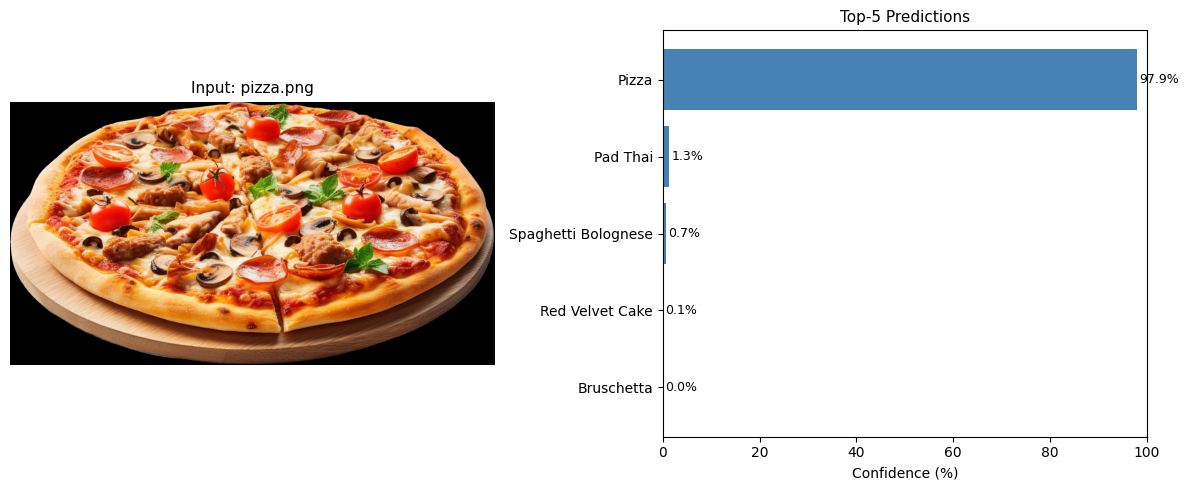


Top prediction: Pizza (97.9% confidence)


In [23]:
def preprocess_for_inference(image_path: str, img_size: tuple = IMG_SIZE) -> np.ndarray:
    """
    Load a single image from disk, resize it, and normalise to [0, 1].
    Returns a batched array of shape (1, H, W, 3).
    """
    img = Image.open(image_path).convert('RGB')
    img = img.resize(img_size)
    arr = np.array(img) / 255.0
    return np.expand_dims(arr, axis=0)  # add batch dimension


def predict_food(image_path: str, top_k: int = 5) -> list:
    """
    Predict the food category of an image.

    Parameters:
        image_path : path to the image file
        top_k      : number of top predictions to return

    Returns:
        List of (class_name, confidence) tuples, sorted by confidence descending.
    """
    img_array = preprocess_for_inference(image_path)
    preds     = model.predict(img_array, verbose=0)[0]  # shape: (101,)
    top_idxs  = np.argsort(preds)[::-1][:top_k]
    return [(INDEX_TO_CLASS[i], float(preds[i])) for i in top_idxs]


def display_prediction(image_path: str, top_k: int = 5) -> None:
    """Display an image alongside its top-k predictions."""
    predictions = predict_food(image_path, top_k=top_k)

    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 5))

    # Left: image
    img = Image.open(image_path).convert('RGB')
    ax_img.imshow(img)
    ax_img.set_title(f'Input: {os.path.basename(image_path)}', fontsize=11)
    ax_img.axis('off')

    # Right: bar chart of top-k confidences
    classes_list = [p[0].replace('_', ' ').title() for p in predictions]
    confs        = [p[1] * 100 for p in predictions]
    bars = ax_bar.barh(classes_list[::-1], confs[::-1], color='steelblue')
    ax_bar.set_xlabel('Confidence (%)')
    ax_bar.set_title(f'Top-{top_k} Predictions', fontsize=11)
    ax_bar.set_xlim(0, 100)
    for bar, conf in zip(bars, confs[::-1]):
        ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                    f'{conf:.1f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f'\nTop prediction: {predictions[0][0].replace("_", " ").title()} ({predictions[0][1]*100:.1f}% confidence)')


# ── Example usage ──────────────────────────────────────────────────────────
# Replace with the path to any food image on your machine:
TEST_IMAGE_PATH = 'C:\\Users\\amber\\Calorie Counter v2\\pizza.png'

if os.path.exists(TEST_IMAGE_PATH):
    display_prediction(TEST_IMAGE_PATH)
else:
    print(f'No image found at {TEST_IMAGE_PATH!r}.')
    print('Update TEST_IMAGE_PATH above and re-run this cell.')

---
## 13. Load a Saved Model (Skip Training)

In [ ]:
# model = tf.keras.models.load_model(MODEL_SAVE_PATH)
# print(f'Model loaded from {MODEL_SAVE_PATH}')
# print(model.summary())